## Experimentation1 : Vectors & Matrix Transformations

In [1]:
# we only need this two libraries for our experimentation
import numpy as np
import matplotlib.pyplot as plt 


In [2]:
#lets say we have a 2D vector [3,2]
v = np.array([3,2])
# we have a 2*2 matrix
W = np.array([[2,-1],[1,1]])
# multiply W@v (method 1)
v_transformed = W@v
print(v_transformed)
# manually using columns times coordinates x and y
col1 = W[:,0]
col2 = W[:,1]
v_transformed2 = 3*col1 + 2*col2
print(v_transformed2)

[4 5]
[4 5]


**we can see that a matrix defines where the `basis vectors` should move and apply them to a vector** 

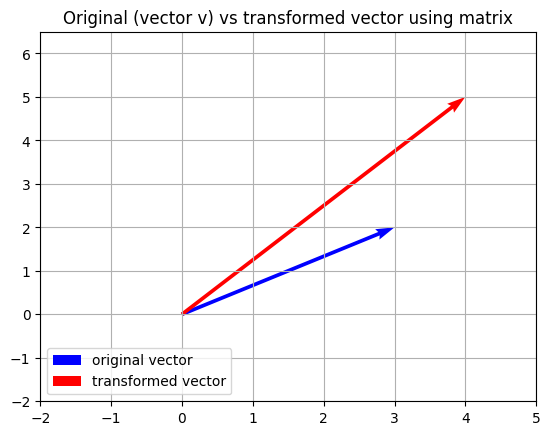

In [3]:
#X,Y are for origin location and U,V for destination location
X=[0]
Y=[0]
U=[3]
V=[2]
## transformed location
P = [4]
W = [5]
plt.quiver(X,Y,U,V,color='b',angles='xy',scale_units='xy',scale=1,label="original vector")
plt.quiver(X,Y,P,W,color='r',angles='xy',scale_units='xy',scale=1,label="transformed vector")
plt.xlim(-2,5)
plt.ylim(-2,6.5)
plt.title("Original (vector v) vs transformed vector using matrix")

plt.grid()
plt.legend(loc=3)
plt.show()

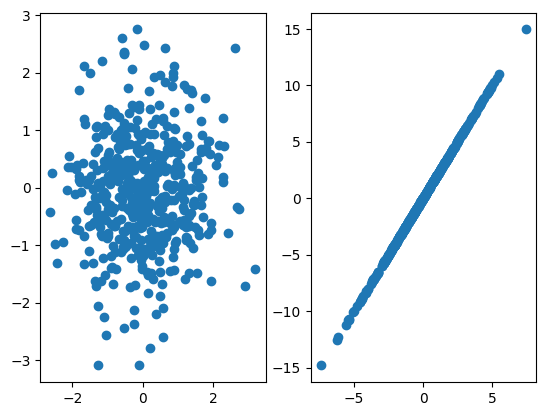

In [4]:
fig,ax = plt.subplots(1,2)
# lets say we have this cloud datapoints
cloud = np.random.randn(2,500)
ax[0].scatter(cloud[0,:],cloud[1,:])
#we gonna apply a transformation using a matrix W_bad
W_bad = np.array([[1,2],[2,4]])
new_cloud = W_bad@cloud
ax[1].scatter(new_cloud[0,:],new_cloud[1,:])


**Remark: A matrix transformation can compress space. Even though we started with a `2D cloud` of points, multiplying it by `W_bad` squashed all the points onto a single `1D line`. The transformation essentially "destroyed" a dimension. Because all the points are crushed onto one line, we can't reverse this process to get our original 2D cloud back (information was lost).**

Text(0.5, 1.0, 'Rotate then shear')

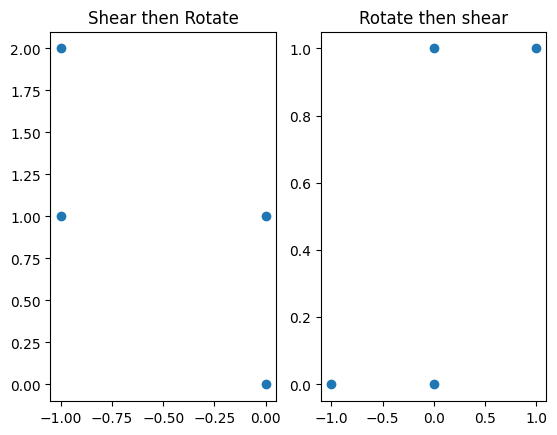

In [5]:
square = np.array([[0,1,1,0],[0,0,1,1]])
R = np.array([[0,-1],[1,0]]) # rotation 90°
S = np.array([[1,1],[0,1]]) # shear matrix

#compare order of transformation R@(S@square) or S@(R@square)
fig,ax = plt.subplots(1,2)
square1 = R@(S@square)
square2 = S@(R@square)
ax[0].scatter(square1[0,:],square1[1,:])
ax[1].scatter(square2[0,:],square2[1,:])
ax[0].set_title("Shear then Rotate")
ax[1].set_title("Rotate then shear")


`Takeaway` : **matrix multiplication is NOT commutative** Rotate then Shear produces a completely different shape than Shear then Rotate, even though you used the exact same two matrices.

## The Volume Determinant Tracker

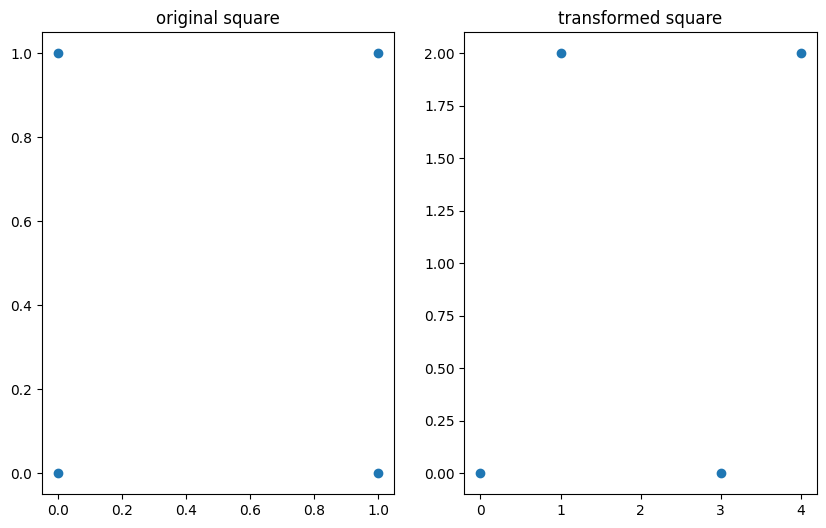

In [6]:
square = np.array([[0,1,1,0],[0,0,1,1]])
W = np.array([[3,1],[0,2]])
det_W = np.linalg.det(W) # perform determinant of the matrix W
transformed_square = W@square 

#visualization
fig,ax = plt.subplots(1,2,figsize=(10,6))

ax[0].scatter(x=square[0,:],y=square[1,:])
ax[1].scatter(x=transformed_square[0,:],y=transformed_square[1,:])

ax[0].set_title("original square")
ax[1].set_title("transformed square")
plt.show()

**we can see that the area of the new plane is `A = height*lenght = 6` and its the same as the determinant of A which is 6 also.**

In [7]:
print(det_W)

6.0


## Inverse Matrices

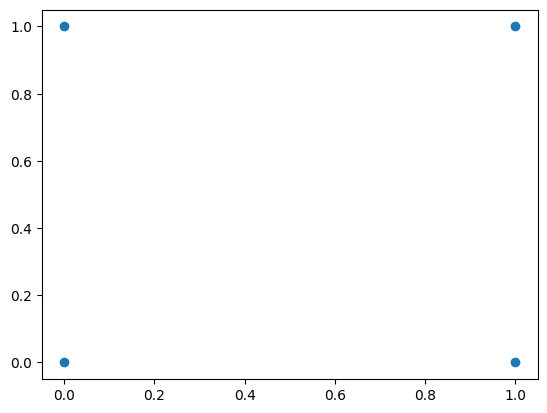

In [8]:
W_inv = np.linalg.inv(W)
restored_square = W_inv@transformed_square
plt.scatter(restored_square[0,:],restored_square[1,:])

In [9]:
W_bad = np.array([[1,2],[2,4]])
squashed = W_bad@square
np.linalg.inv(W_bad)

LinAlgError: Singular matrix

**Engineering Reality**: In code, a `Singular matrix` just means `Determinant is 0`. It means the transformation destroyed information (squashed 2D into 1D), so math physically prevents you from hitting "Undo" because it doesn't know where the points originally came from.

## Finding The Graveyard (Null Space)

In [10]:
from scipy.linalg import null_space
ns = null_space(W_bad) # any vector that lives in the 1D line that got squished
test_vec = 5*ns # a scaled version of the null space
result = W_bad@test_vec # information got erased
print(test_vec)
print(result)


[[-4.47213595]
 [ 2.23606798]]
[[0.]
 [0.]]


## Dot Product / Projection / Similarity

### what is a dot product ?

**definition:** dot product tell us the degree of alignement of two vectors `dot product = 0`:they are perpendicular `(nothing in common)` , `dot product > 0` they share component on the `same direction`, `dot product <0` `opposite direction`.

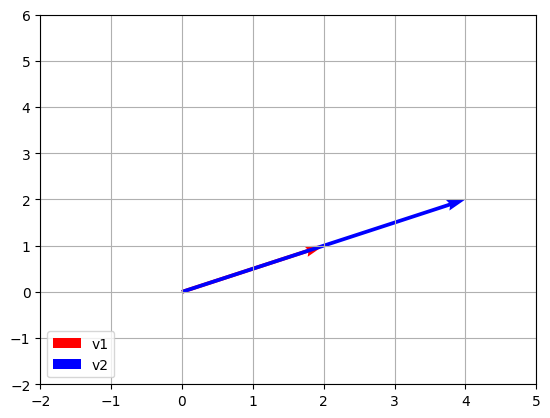

In [11]:
v1_X0 = [0]
v1_Y0 = [0]

v1_X = [2]
v1_Y = [1]

v2_X = [4]
v2_Y = [2]

plt.quiver(v1_X0,v1_Y0,v1_X,v1_Y,color='r',angles='xy',scale_units='xy',scale=1,label="v1")
plt.quiver(v1_X0,v1_Y0,v2_X,v2_Y,color='b',angles='xy',scale_units='xy',scale=1,label="v2")

plt.xlim(-2,5)
plt.ylim(-2,6)
plt.grid()
plt.legend(loc=3)
plt.show()

In [12]:
np.dot([2,1],[4,2])

np.int64(10)

**as we can see dot product positive same direction**

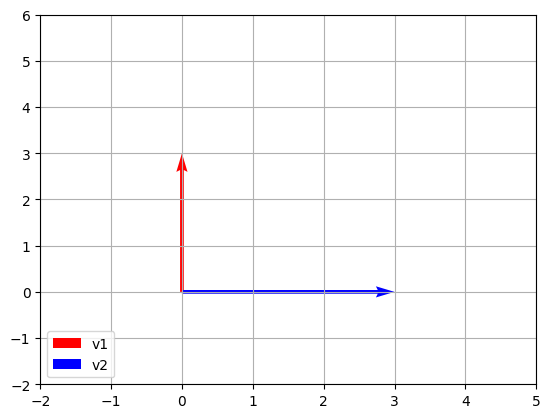

In [13]:
v1_X1 = [0]
v1_Y1 = [3]

v2_X1 = [3]
v2_Y1 = [0]

plt.quiver(v1_X0,v1_Y0,v1_X1,v1_Y1,angles='xy',scale_units='xy',scale=1,color='r',label="v1")
plt.quiver(v1_X0,v1_Y0,v2_X1,v2_Y1,angles='xy',scale_units='xy',scale=1,color='b',label="v2")

plt.grid()
plt.xlim(-2,5)
plt.ylim(-2,6)
plt.legend(loc=3)
plt.show()

In [14]:
#perform dot product
np.dot([0,3],[3,0])

np.int64(0)

**we can see that when two vector have a 0 dot product they are perpendicular or they `share nothing in common`.**

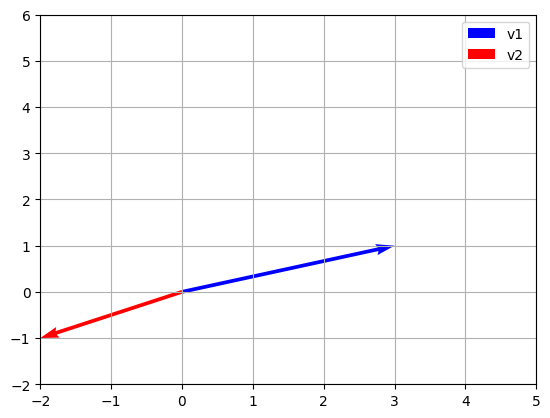

In [15]:
v1_X2 = [3]
v1_Y2 = [1]

v2_X2 = [-2]
v2_Y2 = [-1]

plt.quiver(v1_X0,v1_Y0,v1_X2,v1_Y2,angles='xy',scale_units='xy',scale=1,color='b',label="v1")
plt.quiver(v1_X0,v1_Y0,v2_X2,v2_Y2,angles='xy',scale_units='xy',scale=1,color='r',label="v2")

plt.grid()
plt.legend(loc=1)
plt.xlim(-2,5)
plt.ylim(-2,6)

plt.show()

In [16]:
np.dot([3,1],[-2,-1])

np.int64(-7)

**we can see that negative dot product means the two vectors share `opposite direction`.**

### what is projection ?

**projection help you extract a component from a vector**

In [17]:
x = np.array([4,3]) # signal vector
n = np.array([1,1]) # noise vector

#the goal here is to extract the part of signal that is in the noise direction 
# so we have to project x onto n
dot_product = np.dot(x,n)
n_product = np.dot(n,n)
c = (dot_product/n_product)
proj = c*n
print(proj)
residual = x-proj
print(residual) # component that is not in the direction of noise 

[3.5 3.5]
[ 0.5 -0.5]


In [18]:
#we can verify that by performing dot product of residual and n (noise)
print(np.dot(residual,n))

0.0


### EigenValues And EigenVectors

In [19]:
np.random.seed(42)
n = 300

age = np.random.randint(20, 80, n).astype(float)
weight_kg = np.random.normal(75, 15, n)
height_cm = np.random.normal(170, 10, n)
bmi = weight_kg / (height_cm / 100) ** 2      # derived feature
systolic_bp = 0.4 * age + np.random.normal(80, 10, n)
diastolic_bp = 0.6 * systolic_bp + np.random.normal(10, 5, n)  # correlated

X = np.column_stack([age, weight_kg, height_cm, bmi, systolic_bp, diastolic_bp])
feature_names = ['age', 'weight_kg', 'height_cm', 'bmi', 'systolic_bp', 'diastolic_bp']

In [22]:
print(X[:10])

[[ 58.          67.59851277 169.85281741  23.43104354  99.71986914
   61.66716008]
 [ 71.          88.84743913 177.9640543   28.05306593 110.38558363
   73.36750805]
 [ 48.         100.59907431 167.18614893  35.99095713  84.85635033
   64.91630141]
 [ 34.          88.10384123 153.35306804  37.4636343   99.4102201
   70.54250508]
 [ 62.          75.13716519 169.9380086   26.01799083  89.55984758
   66.40020801]
 [ 27.          69.51691055 174.03119327  22.95283143  82.81560953
   53.42032455]
 [ 40.          84.73630099 181.22677685  25.80030076 109.4131192
   82.53188898]
 [ 58.          56.65689695 155.5880424   23.40455304  94.36222211
   70.50241375]
 [ 77.          83.04504049 168.77088693  29.15537527 116.53966959
   81.93192928]
 [ 38.          61.27963603 169.24696345  21.39313374  77.66426282
   53.17050629]]


**The Problem** we cannot find eigenvectors of 300x6 matrix because its not square , so we build the `Covarience Matrix`.
The `Covarience Matrix` is 6x6 matrix where each entry (i,j) tells you how much feature i and j move together.

In [27]:
#normalize each feature to zero mean
X_centered = X - X.mean(axis=0)
C = (X_centered.T@X_centered)/n # 6x300 @ 300x6 = 6x6 (dot product of every feature with every other feature)
print(C.shape)

(6, 6)


**we know that dot product is the same as similarity**

[  0.45253404  15.28228654  98.55274076 116.00908119 253.54548645
 437.41547862]


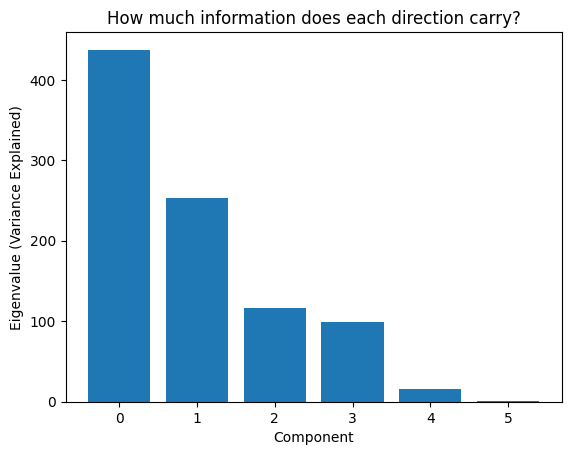

In [31]:
eigenvalues,eigenvectors = np.linalg.eigh(C)
print(eigenvalues)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[idx]

plt.bar(range(6),eigenvalues)
plt.xlabel('Component')
plt.ylabel('Eigenvalue (Variance Explained)')
plt.title('How much information does each direction carry?')
plt.show()